In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../backend/datasets/water_consumption_processed.csv")

df["Datetime"] = pd.to_datetime(df["Datetime"])

df = df.sort_values("Datetime").reset_index(drop=True)

df.head()

,Date,Time,Consumption,Temperature,Rain,Sun,StartTime,Datetime,Hour,Day,Month,DayOfWeek,IsWeekend
0,1/1/2016,00:00-01:00,1480,0.6,0.0,0,00:00,2016-01-01 00:00:00,0,1,1,4,0
1,1/1/2016,01:00-02:00,1362,0.6,0.0,0,01:00,2016-01-01 01:00:00,1,1,1,4,0
2,1/1/2016,02:00-03:00,1296,0.5,0.0,0,02:00,2016-01-01 02:00:00,2,1,1,4,0
3,1/1/2016,03:00-04:00,1096,0.0,0.0,0,03:00,2016-01-01 03:00:00,3,1,1,4,0
4,1/1/2016,04:00-05:00,810,0.3,0.0,0,04:00,2016-01-01 04:00:00,4,1,1,4,0


In [87]:
df["Consumption_Lag_1"] = df["Consumption"].shift(1)

df["Consumption_Lag_24"] = df["Consumption"].shift(24)

df["Consumption_Lag_168"] = df["Consumption"].shift(168)

In [88]:
df["Rolling_Mean_24"] = (
    df["Consumption"]
    .shift(1)
    .rolling(window=24)
    .mean()
)

df["Rolling_Mean_168"] = (
    df["Consumption"]
    .shift(1)
    .rolling(window=168)
    .mean()
)

df = df.dropna().reset_index(drop=True)

df.shape

(45863, 18)

In [89]:
features = [
    "Temperature",
    "Rain",
    "Sun",
    "Hour",
    "Day",
    "Month",
    "DayOfWeek",
    "IsWeekend",
    "Consumption_Lag_1",
    "Consumption_Lag_24",
    "Consumption_Lag_168",
    "Rolling_Mean_24",
    "Rolling_Mean_168"
]

X = df[features]
y = df["Consumption"]

In [90]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [91]:
from sklearn.ensemble import RandomForestRegressor

rf_improved = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_improved.fit(X_train, y_train)

predictions_improved = rf_improved.predict(X_test)

comparison_improved = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions_improved
})

comparison_improved.head(10)

,Actual,Predicted
0,2516,2636.525
1,2755,2640.565
2,2474,2535.220
3,1759,1821.910
4,1515,1587.615
5,1412,1473.110
6,1509,1231.100
7,1136,1028.390
8,591,789.460
9,735,590.050


In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_improved = mean_absolute_error(
    y_test,
    predictions_improved
)

rmse_improved = np.sqrt(
    mean_squared_error(
        y_test,
        predictions_improved
    )
)

r2_improved = r2_score(
    y_test,
    predictions_improved
)

print("Improved Model")
print("MAE :", mae_improved)
print("RMSE:", rmse_improved)
print("R²  :", r2_improved)

Improved Model
MAE : 182.3491104327919
RMSE: 250.64550160930747
R²  : 0.9490945983698682


In [93]:
results = pd.DataFrame({
    "Datetime": df.iloc[split_index:]["Datetime"].values,
    "Actual": y_test.values,
    "Predicted": predictions_improved
})

results["Error"] = results["Actual"] - results["Predicted"]

results["Absolute_Error"] = abs(results["Error"])

results["Percentage_Deviation"] = (
    abs(results["Error"]) / results["Predicted"]
) * 100

results.head(10)

,Datetime,Actual,Predicted,Error,Absolute_Error,Percentage_Deviation
0,2020-03-15 18:00:00,2516,2636.525,-120.525,120.525,4.571358
1,2020-03-15 19:00:00,2755,2640.565,114.435,114.435,4.333732
2,2020-03-15 20:00:00,2474,2535.220,-61.220,61.220,2.414781
3,2020-03-15 21:00:00,1759,1821.910,-62.910,62.910,3.452970
4,2020-03-15 22:00:00,1515,1587.615,-72.615,72.615,4.573842
5,2020-03-15 23:00:00,1412,1473.110,-61.110,61.110,4.148366
6,2020-03-16 00:00:00,1509,1231.100,277.900,277.900,22.573308
7,2020-03-16 01:00:00,1136,1028.390,107.610,107.610,10.463929
8,2020-03-16 02:00:00,591,789.460,-198.460,198.460,25.138702
9,2020-03-16 03:00:00,735,590.050,144.950,144.950,24.565715


In [94]:
def classify_risk(deviation):
    if deviation <= q75:
        return "Normal"
    elif deviation <= q90:
        return "Warning"
    elif deviation <= q95:
        return "High"
    else:
        return "Critical"


results["Risk"] = results["Percentage_Deviation"].apply(classify_risk)

In [95]:
results["Risk"].value_counts()

Risk
Normal      6880
Warning     1375
High         459
Critical     459
Name: count, dtype: int64

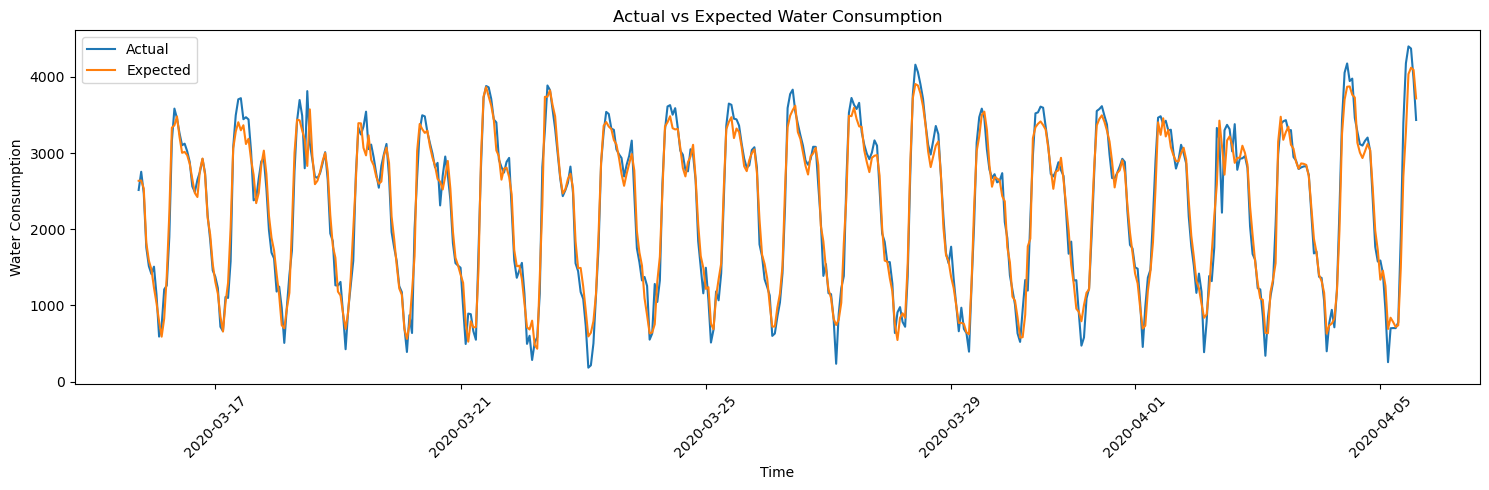

In [96]:
plt.figure(figsize=(15, 5))

plt.plot(
    results["Datetime"][:500],
    results["Actual"][:500],
    label="Actual"
)

plt.plot(
    results["Datetime"][:500],
    results["Predicted"][:500],
    label="Expected"
)

plt.xlabel("Time")
plt.ylabel("Water Consumption")
plt.title("Actual vs Expected Water Consumption")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [97]:
results["Percentage_Deviation"].describe()

count    9173.000000
mean        9.344170
std        11.216225
min         0.000183
25%         2.471813
50%         5.509661
75%        11.510690
max       130.998814
Name: Percentage_Deviation, dtype: float64

In [98]:
results["Percentage_Deviation"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
)

0.50     5.509661
0.75    11.510690
0.90    22.408366
0.95    31.976142
0.99    56.348945
Name: Percentage_Deviation, dtype: float64

In [99]:
q75 = results["Percentage_Deviation"].quantile(0.75)
q90 = results["Percentage_Deviation"].quantile(0.90)
q95 = results["Percentage_Deviation"].quantile(0.95)

print("75th percentile:", q75)
print("90th percentile:", q90)
print("95th percentile:", q95)

75th percentile: 11.510689508707342
90th percentile: 22.408366053462853
95th percentile: 31.97614191218333


In [100]:
risk_percentages = (
    results["Risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

risk_percentages

Risk
Normal      75.00
Warning     14.99
High         5.00
Critical     5.00
Name: proportion, dtype: float64

In [101]:
results["Is_Anomaly"] = (
    results["Percentage_Deviation"] > q90
).astype(int)

In [102]:
results["Anomaly_Group"] = (
    results["Is_Anomaly"]
    .ne(results["Is_Anomaly"].shift())
    .cumsum()
)

results["Consecutive_Anomaly"] = (
    results.groupby("Anomaly_Group")
    .cumcount() + 1
)

results.loc[
    results["Is_Anomaly"] == 0,
    "Consecutive_Anomaly"
] = 0

In [103]:
results[
    ["Datetime", "Percentage_Deviation",
     "Risk", "Is_Anomaly", "Consecutive_Anomaly"]
].head(30)

,Datetime,Percentage_Deviation,Risk,Is_Anomaly,Consecutive_Anomaly
0,2020-03-15 18:00:00,4.571358,Normal,0,0
1,2020-03-15 19:00:00,4.333732,Normal,0,0
2,2020-03-15 20:00:00,2.414781,Normal,0,0
3,2020-03-15 21:00:00,3.452970,Normal,0,0
4,2020-03-15 22:00:00,4.573842,Normal,0,0
5,2020-03-15 23:00:00,4.148366,Normal,0,0
6,2020-03-16 00:00:00,22.573308,High,1,1
7,2020-03-16 01:00:00,10.463929,Normal,0,0
8,2020-03-16 02:00:00,25.138702,High,1,1
9,2020-03-16 03:00:00,24.565715,High,1,2


In [104]:
def assess_final_risk(row):
    deviation = row["Percentage_Deviation"]
    consecutive = row["Consecutive_Anomaly"]

    if deviation <= q75:
        return "Normal"

    elif deviation <= q90:
        return "Warning"

    elif deviation <= q95:
        return "High"

    elif consecutive >= 3:
        return "Critical"

    else:
        return "High"

In [105]:
results["Final_Risk"] = results.apply(
    assess_final_risk,
    axis=1
)

In [106]:
results["Final_Risk"].value_counts()

Final_Risk
Normal      6880
Warning     1375
High         873
Critical      45
Name: count, dtype: int64

In [107]:
results["Risk"] = results["Percentage_Deviation"].apply(classify_risk)

In [108]:
results["Risk"].value_counts()

Risk
Normal      6880
Warning     1375
High         459
Critical     459
Name: count, dtype: int64

In [109]:
results[
    ["Datetime", "Percentage_Deviation",
     "Risk", "Is_Anomaly", "Consecutive_Anomaly"]
].head(30)


,Datetime,Percentage_Deviation,Risk,Is_Anomaly,Consecutive_Anomaly
0,2020-03-15 18:00:00,4.571358,Normal,0,0
1,2020-03-15 19:00:00,4.333732,Normal,0,0
2,2020-03-15 20:00:00,2.414781,Normal,0,0
3,2020-03-15 21:00:00,3.452970,Normal,0,0
4,2020-03-15 22:00:00,4.573842,Normal,0,0
5,2020-03-15 23:00:00,4.148366,Normal,0,0
6,2020-03-16 00:00:00,22.573308,High,1,1
7,2020-03-16 01:00:00,10.463929,Normal,0,0
8,2020-03-16 02:00:00,25.138702,High,1,1
9,2020-03-16 03:00:00,24.565715,High,1,2


In [110]:
results["Positive_Deviation"] = (
    (results["Actual"] - results["Predicted"])
    / results["Predicted"]
) * 100

results["Positive_Deviation"] = results["Positive_Deviation"].clip(lower=0)

In [111]:
results[
    ["Datetime", "Actual", "Predicted",
     "Positive_Deviation"]
].head(20)

,Datetime,Actual,Predicted,Positive_Deviation
0,2020-03-15 18:00:00,2516,2636.525,0.000000
1,2020-03-15 19:00:00,2755,2640.565,4.333732
2,2020-03-15 20:00:00,2474,2535.220,0.000000
3,2020-03-15 21:00:00,1759,1821.910,0.000000
4,2020-03-15 22:00:00,1515,1587.615,0.000000
5,2020-03-15 23:00:00,1412,1473.110,0.000000
6,2020-03-16 00:00:00,1509,1231.100,22.573308
7,2020-03-16 01:00:00,1136,1028.390,10.463929
8,2020-03-16 02:00:00,591,789.460,0.000000
9,2020-03-16 03:00:00,735,590.050,24.565715


In [112]:
positive_deviation = results.loc[
    results["Positive_Deviation"] > 0,
    "Positive_Deviation"
]

positive_deviation.quantile(
    [0.75, 0.90, 0.95, 0.99]
)

0.75    10.886029
0.90    19.994347
0.95    27.280943
0.99    49.959070
Name: Positive_Deviation, dtype: float64

In [113]:
q75_leak = positive_deviation.quantile(0.75)
q90_leak = positive_deviation.quantile(0.90)
q95_leak = positive_deviation.quantile(0.95)

In [114]:
print("75th percentile:", q75_leak)
print("90th percentile:", q90_leak)
print("95th percentile:", q95_leak)

75th percentile: 10.886029022349332
90th percentile: 19.994347135573502
95th percentile: 27.280943219278214


In [115]:
def classify_leakage_risk(row):
    deviation = row["Positive_Deviation"]
    consecutive = row["Consecutive_Anomaly"]

    if deviation <= q75_leak:
        return "Normal"

    elif deviation <= q90_leak:
        return "Warning"

    elif deviation <= q95_leak:
        return "High"

    elif consecutive >= 3:
        return "Critical"

    else:
        return "High"

In [116]:
results["Leakage_Risk"] = results.apply(
    classify_leakage_risk,
    axis=1
)

In [117]:
results["Leakage_Risk"].value_counts()

Leakage_Risk
Normal      7930
Warning      745
High         469
Critical      29
Name: count, dtype: int64

In [118]:
def calculate_risk_score(row):
    deviation = row["Positive_Deviation"]
    consecutive = row["Consecutive_Anomaly"]

    deviation_score = min(
        (deviation / q95_leak) * 80,
        80
    )

    persistence_score = min(
        consecutive * 5,
        20
    )

    return round(
        deviation_score + persistence_score,
        2
    )

results["Risk_Score"] = results.apply(
    calculate_risk_score,
    axis=1
)

In [119]:
anomaly_results = results[
    [
        "Datetime",
        "Actual",
        "Predicted",
        "Positive_Deviation",
        "Consecutive_Anomaly",
        "Leakage_Risk",
        "Risk_Score"
    ]
].copy()

In [120]:
anomaly_results.head(20)

,Datetime,Actual,Predicted,Positive_Deviation,Consecutive_Anomaly,Leakage_Risk,Risk_Score
0,2020-03-15 18:00:00,2516,2636.525,0.000000,0,Normal,0.00
1,2020-03-15 19:00:00,2755,2640.565,4.333732,0,Normal,12.71
2,2020-03-15 20:00:00,2474,2535.220,0.000000,0,Normal,0.00
3,2020-03-15 21:00:00,1759,1821.910,0.000000,0,Normal,0.00
4,2020-03-15 22:00:00,1515,1587.615,0.000000,0,Normal,0.00
5,2020-03-15 23:00:00,1412,1473.110,0.000000,0,Normal,0.00
6,2020-03-16 00:00:00,1509,1231.100,22.573308,1,High,71.20
7,2020-03-16 01:00:00,1136,1028.390,10.463929,0,Normal,30.68
8,2020-03-16 02:00:00,591,789.460,0.000000,1,Normal,5.00
9,2020-03-16 03:00:00,735,590.050,24.565715,2,High,82.04


In [121]:
import os

os.makedirs("../backend/results", exist_ok=True)

anomaly_results.to_csv(
    "../backend/results/water_anomaly_results.csv",
    index=False
)

In [122]:
print(percentile_values)

NameError: name 'percentile_values' is not defined

In [123]:
print(anomaly_results["Leakage_Risk"].value_counts())

Leakage_Risk
Normal      7930
Warning      745
High         469
Critical      29
Name: count, dtype: int64
